# Import library

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shutil
import random
from glob import glob
import csv
from collections import defaultdict
import cv2
import albumentations as A
import re

# 1. Split data into train/val/test.

In [2]:
# ==== CONFIG ====
DATA_DIR = "dataset"   # root dataset folder
TRAIN_RATIO = 0.7      # 70% for training
VAL_RATIO = 0.2        # 20% for validation
TEST_RATIO = 0.1       # 10% for testing
# =================

IMAGES_DIR = os.path.join(DATA_DIR, "images")
LABELS_DIR = os.path.join(DATA_DIR, "labels")

# Get image filenames (without extension)
image_files = [f for f in os.listdir(IMAGES_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
image_stems = [os.path.splitext(f)[0] for f in image_files]

# Shuffle the list for random split
random.seed(42)
random.shuffle(image_stems)

# Calculate split sizes
n_total = len(image_stems)
n_train = int(n_total * TRAIN_RATIO)
n_val = int(n_total * VAL_RATIO)

train_stems = image_stems[:n_train]
val_stems = image_stems[n_train:n_train+n_val]
test_stems = image_stems[n_train+n_val:]

splits = {
    "train": train_stems,
    "val": val_stems,
    "test": test_stems
}

# Create output folders for each split
for split in splits:
    os.makedirs(os.path.join(DATA_DIR, "images", split), exist_ok=True)
    os.makedirs(os.path.join(DATA_DIR, "labels", split), exist_ok=True)

# Move images and corresponding label files
def move_files(stems, split):
    for stem in stems:
        # Move image file
        for ext in (".jpg", ".jpeg", ".png"):
            img_src = os.path.join(IMAGES_DIR, stem + ext)
            if os.path.exists(img_src):
                img_dst = os.path.join(IMAGES_DIR, split, stem + ext)
                shutil.move(img_src, img_dst)
                break
        # Move label file (empty if missing)
        label_src = os.path.join(LABELS_DIR, stem + ".txt")
        if os.path.exists(label_src):
            label_dst = os.path.join(LABELS_DIR, split, stem + ".txt")
            shutil.move(label_src, label_dst)
        else:
            open(os.path.join(LABELS_DIR, split, stem + ".txt"), "w").close()

# Perform move for each split
for split, stems in splits.items():
    move_files(stems, split)

print(f"Total images: {n_total}")
for split in splits:
    print(f"{split}: {len(splits[split])} images")

Total images: 949
train: 664 images
val: 189 images
test: 96 images


# plot_class_distribution

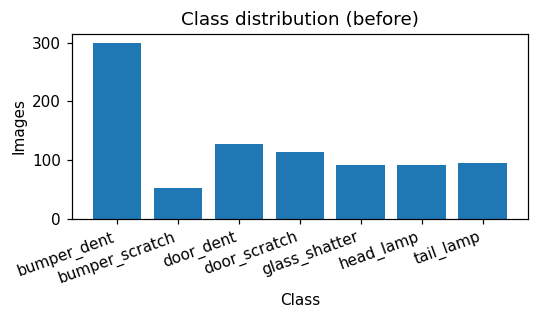

bumper_dent: 300
bumper_scratch: 53
door_dent: 128
door_scratch: 113
glass_shatter: 92
head_lamp: 92
tail_lamp: 95


In [6]:
def plot_class_distribution(dataset_dir: str, split: str, title: str):
    img_dir = os.path.join(dataset_dir, "images", split)
    lbl_dir = os.path.join(dataset_dir, "labels", split)
    classes_txt = os.path.join(dataset_dir, "classes.txt")

    # collect image stems
    img_exts = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
    stems = []
    for p in glob(os.path.join(img_dir, "*")):
        name, ext = os.path.splitext(os.path.basename(p))
        if ext.lower() in img_exts:
            stems.append(name)
    stems.sort()
    if not stems:
        raise RuntimeError(f"No images found in: {img_dir}")

    # class names (optional)
    class_names = []
    if os.path.exists(classes_txt):
        with open(classes_txt, "r", encoding="utf-8") as f:
            class_names = [ln.strip() for ln in f if ln.strip()]

    # read class id of each image (robust to '0.0' and empty lines)
    class_ids = []
    for s in stems:
        with open(os.path.join(lbl_dir, s + ".txt"), "r", encoding="utf-8") as f:
            cid = None
            for raw in f:
                line = raw.strip()
                if not line:
                    continue
                parts = line.split()
                if len(parts) >= 1:
                    cid = int(float(parts[0]))  # <-- key fix
                    break
            if cid is None:
                raise ValueError(f"No valid label line in: {s}.txt")
        class_ids.append(cid)

    # count by class
    n_classes = len(class_names) if class_names else (max(class_ids) + 1)
    counts = [0] * n_classes
    for cid in class_ids:
        if 0 <= cid < n_classes:
            counts[cid] += 1

    xlabels = [class_names[i] if i < len(class_names) else f"class_{i}" for i in range(n_classes)]

    # show chart (no save)
    plt.figure(figsize=(5, 3), dpi=110)
    plt.bar(xlabels, counts)
    plt.xlabel("Class")
    plt.ylabel("Images")
    plt.title(f"Class distribution ({title})")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

    # print counts
    for name, c in zip(xlabels, counts):
        print(f"{name}: {c}")

plot_class_distribution("dataset", "train","before")

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_28960\530284348.py:19: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 25.0), p=0.25),
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_28960\530284348.py:20: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=45, quality_upper=90, p=0.4),


Before:
  bumper_dent: 300
  bumper_scratch: 53
  door_dent: 128
  door_scratch: 113
  glass_shatter: 92
  head_lamp: 92
  tail_lamp: 95
Target per class: 300


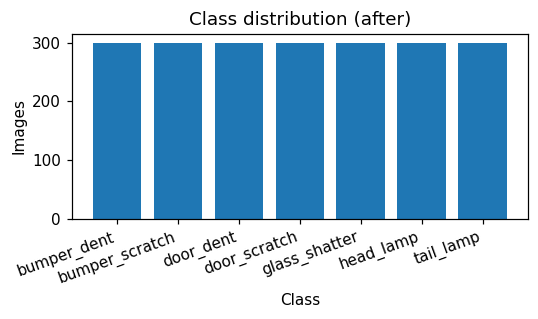

bumper_dent: 300
bumper_scratch: 300
door_dent: 300
door_scratch: 300
glass_shatter: 300
head_lamp: 300
tail_lamp: 300


In [8]:
# ===== SETTINGS =====
DATASET_DIR = "dataset"
SPLIT = "train"              # augment only this split
TARGET_PER_CLASS = 300       # images/class after augmentation (min)
IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
MAX_COPIES_PER_SRC = 6       # avoid overusing one source image

random.seed(42)
IMG_DIR = os.path.join(DATASET_DIR, "images", SPLIT)
LBL_DIR = os.path.join(DATASET_DIR, "labels", SPLIT)
CLASSES_TXT = os.path.join(DATASET_DIR, "classes.txt")

# Photometric-only transforms
transform = A.Compose([
    A.RandomBrightnessContrast(p=0.6),
    A.HueSaturationValue(p=0.4),
    A.RandomGamma(p=0.3),
    A.CLAHE(clip_limit=2.0, p=0.2),
    A.GaussNoise(var_limit=(5.0, 25.0), p=0.25),
    A.ImageCompression(quality_lower=45, quality_upper=90, p=0.4),
    A.ToGray(p=0.15),
])

# helpers (minimal) 
def list_stems():
    """List image filename stems in the split folder."""
    stems = []
    for p in glob(os.path.join(IMG_DIR, "*")):
        n, ext = os.path.splitext(os.path.basename(p))
        if ext.lower() in IMG_EXTS:
            stems.append(n)
    stems.sort()
    if not stems:
        raise RuntimeError(f"No images found in {IMG_DIR}")
    return stems

def find_img_path(stem):
    # Find actual image path and extension for a given stem.
    for ext in IMG_EXTS:
        p = os.path.join(IMG_DIR, stem + ext)
        if os.path.exists(p): return p, ext.lower()
    return None, None

def read_class_id(stem):
    """Read class id (tolerates '0.0' style ids)."""
    with open(os.path.join(LBL_DIR, stem + ".txt"), "r", encoding="utf-8") as f:
        for raw in f:
            line = raw.strip()
            if line:
                return int(float(line.split()[0]))
    raise ValueError(f"No valid label in {stem}.txt")

def copy_label(src_stem, dst_stem):
    shutil.copyfile(os.path.join(LBL_DIR, src_stem + ".txt"),
                    os.path.join(LBL_DIR, dst_stem + ".txt"))

def read_class_names():
    if os.path.exists(CLASSES_TXT):
        with open(CLASSES_TXT, "r", encoding="utf-8") as f:
            return [ln.strip() for ln in f if ln.strip()]
    return []

def safe_name(s):
    return re.sub(r"[^A-Za-z0-9_-]+", "_", s)

# -------- build pools & counts --------
stems = list_stems()
class_names = read_class_names()

pool_by_class = defaultdict(list)   # cid -> [stems]
for s in stems:
    cid = read_class_id(s)          # 1 bbox/image: class id per image
    pool_by_class[cid].append(s)

n_classes = len(class_names) if class_names else (max(pool_by_class.keys()) + 1)
counts = {cid: len(pool_by_class.get(cid, [])) for cid in range(n_classes)}

def cname(cid):
    return class_names[cid] if cid < len(class_names) else f"class_{cid}"

print("Before:")
for cid in range(n_classes):
    print(f"  {cname(cid)}: {counts[cid]}")

target = max(TARGET_PER_CLASS, max(counts.values()) if counts else 0)
print("Target per class:", target)

copies_per_src = defaultdict(int)
created = 0

# -------- oversample by image-only augmentation --------
for cid in range(n_classes):
    need = target - counts[cid]
    if need <= 0 or not pool_by_class.get(cid):
        continue

    label_tag = safe_name(cname(cid))
    i = 0
    while i < need:
        src = random.choice(pool_by_class[cid])
        if copies_per_src[src] >= MAX_COPIES_PER_SRC:
            continue
        ipath, ext = find_img_path(src)
        if not ipath:
            continue

        img = cv2.imread(ipath)
        out_img = transform(image=img)["image"]  # <-- no bboxes passed

        new_stem = f"{src}__aug_{label_tag}_{i:03d}"
        cv2.imwrite(os.path.join(IMG_DIR, new_stem + ext), out_img)
        copy_label(src, new_stem)                # keep label unchanged

        pool_by_class[cid].append(new_stem)
        counts[cid] += 1
        copies_per_src[src] += 1
        created += 1
        i += 1

plot_class_distribution("dataset", "train","after")